<a href="https://colab.research.google.com/github/onlookertozip/bigStudy/blob/master/%EA%B8%B0%EC%88%A0%ED%86%B5%EA%B3%84_%EC%97%B0%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 기술통계 처리

import pandas as pd

url='titanic.csv'

titanic_csv=pd.read_csv(url)

In [ ]:
titanic_csv.head(5)

,Class,Gender,Age,Survived,Freq
0,1st,Male,Child,No,0
1,2nd,Male,Child,No,0
2,3rd,Male,Child,No,35
3,Crew,Male,Child,No,0
4,1st,Female,Child,No,0


In [ ]:
# 통계값 계산

print('최대값: ',titanic_csv['Freq'].max())
print('최솟값: ',titanic_csv['Freq'].min())
print('평균: ',titanic_csv['Freq'].mean())
print('합: ',titanic_csv['Freq'].sum())
print('카운트: ',titanic_csv['Freq'].count())
print('표준편차: ',titanic_csv['Freq'].std())
print('분산: ',titanic_csv['Freq'].var())

최대값:  670
최솟값:  0
평균:  68.78125
합:  2201
카운트:  32
표준편차:  135.99590467624265
분산:  18494.886088709678


In [ ]:
titanic_csv['Freq'].describe()

count     32.000000
mean      68.781250
std      135.995905
min        0.000000
25%        0.750000
50%       13.500000
75%       77.000000
max      670.000000
Name: Freq, dtype: float64

고유값 유니크 한 값 - 범주형 데이터


In [ ]:
titanic_csv['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
titanic_csv['Gender'].value_counts()

Male      16
Female    16
Name: Gender, dtype: int64

In [ ]:
titanic_csv['Class'].()nunique

4

In [ ]:
titanic_csv['Class'].unique()

array(['1st', '2nd', '3rd', 'Crew'], dtype=object)

In [ ]:
titanic_csv['Class'].value_counts()

2nd     8
Crew    8
1st     8
3rd     8
Name: Class, dtype: int64

결측치-누락된 값 Na

In [ ]:
titanic_csv[titanic_csv['Age'].isnull()].head(5)

,Class,Gender,Age,Survived,Freq


In [ ]:
# 결측치 처리
import numpy as np

titanic_csv['Gender']=titanic_csv['Gender'].replace('Male',np.nan)

In [ ]:
# 결측치 값 설정
titanic_csv=pd.read_csv(url, na_values=[np.nan, 'NONE', -999])

In [ ]:
titanic_csv.head(5)

,Class,Gender,Age,Survived,Freq
0,1st,Male,Child,No,0
1,2nd,Male,Child,No,0
2,3rd,Male,Child,No,35
3,Crew,Male,Child,No,0
4,1st,Female,Child,No,0


# 열/행 삭제 방법

열 삭제

In [ ]:
import pandas as pd

url='titanic.csv'

titanic_csv=pd.read_csv(url)

In [ ]:
titanic_csv.head(5)

,Class,Gender,Age,Survived,Freq
0,1st,Male,Child,No,0
1,2nd,Male,Child,No,0
2,3rd,Male,Child,No,35
3,Crew,Male,Child,No,0
4,1st,Female,Child,No,0


In [ ]:
# 나이 열 삭제
titanic_csv.drop('Age', axis=1).head(5)

,Class,Gender,Survived,Freq
0,1st,Male,No,0
1,2nd,Male,No,0
2,3rd,Male,No,35
3,Crew,Male,No,0
4,1st,Female,No,0


행 삭제

In [ ]:
titanic_csv.head(5)

,Class,Gender,Age,Survived,Freq
0,1st,Male,Child,No,0
1,2nd,Male,Child,No,0
2,3rd,Male,Child,No,35
3,Crew,Male,Child,No,0
4,1st,Female,Child,No,0


In [ ]:
# Male을 삭제
titanic_csv[titanic_csv['Gender'] != 'Male'].head(5)

,Class,Gender,Age,Survived,Freq
4,1st,Female,Child,No,0
5,2nd,Female,Child,No,0
6,3rd,Female,Child,No,17
7,Crew,Female,Child,No,0
12,1st,Female,Adult,No,4


In [ ]:
# 첫번째 행 삭제
titanic_csv[titanic_csv.index != 0].head(5)

,Class,Gender,Age,Survived,Freq
1,2nd,Male,Child,No,0
2,3rd,Male,Child,No,35
3,Crew,Male,Child,No,0
4,1st,Female,Child,No,0
5,2nd,Female,Child,No,0


중복되어진 행 삭제

In [ ]:
titanic_csv.drop_duplicates().head(5)

,Class,Gender,Age,Survived,Freq
0,1st,Male,Child,No,0
1,2nd,Male,Child,No,0
2,3rd,Male,Child,No,35
3,Crew,Male,Child,No,0
4,1st,Female,Child,No,0


In [ ]:
print("원본 데이터 행의 개수:", len(titanic_csv))
print("중복 삭제 후 행의 개수:", len(titanic_csv.drop_duplicates()))

원본 데이터 행의 개수: 32
중복 삭제 후 행의 개수: 32


In [ ]:
# 특정 열에 대해 중복된 행 삭제
titanic_csv.drop_duplicates(subset=['Age'])

,Class,Gender,Age,Survived,Freq
0,1st,Male,Child,No,0
8,1st,Male,Adult,No,118


# 그룹핑

값에 따라 행 그룹핑하기

In [ ]:
# 성별에 따른 행 그룹핑과 평균 구하기
titanic_csv.groupby('Gender').mean()

,Freq
Gender,
Female,29.3750
Male,108.1875


In [ ]:
titanic_csv.groupby(['Class','Gender']).mean()

Freq
Class Gender        
1st   Female   36.25
      Male     45.00
2nd   Female   26.50
      Male     44.75
3rd   Female   49.00
      Male    127.50
Crew  Female    5.75
      Male    215.50

In [ ]:
titanic_csv.groupby(['Class','Gender'])['Freq'].mean()

Class  Gender
1st    Female     36.25
       Male       45.00
2nd    Female     26.50
       Male       44.75
3rd    Female     49.00
       Male      127.50
Crew   Female      5.75
       Male      215.50
Name: Freq, dtype: float64

시간에 따라 행을 그룹핑하기

In [ ]:
import pandas as pd
import numpy as np

#날짜 범위 생성
day_index=pd.date_range('14/01/2001', periods=100000, freq='25T')

In [ ]:
#데이터 프레임 생성
df1=pd.DataFrame(index=day_index)

In [ ]:
df1.head(5)

""
2001-01-14 00:00:00
2001-01-14 00:25:00
2001-01-14 00:50:00
2001-01-14 01:15:00
2001-01-14 01:40:00


In [ ]:
# 임의의 열을 난수 값으로 만듭니다.
df1['Temp']=np.random.randint(1, 10, 100000)

In [ ]:
# 주 단위로 행을 그룹핑한 다음 합을 계산

df1.resample('W').sum()

,Temp
2001-01-14,295
2001-01-21,2016
2001-01-28,2089
2001-02-04,2006
2001-02-11,2043
...,...
2005-09-18,2071
2005-09-25,2010
2005-10-02,2038
2005-10-09,1994


In [ ]:
df1.head(5)

,Temp
2001-01-14 00:00:00,4
2001-01-14 00:25:00,5
2001-01-14 00:50:00,7
2001-01-14 01:15:00,7
2001-01-14 01:40:00,9


In [ ]:
# 2주 단위 그룹핑하고 평균을 계산
df1.resample('2W').sum()

,Temp
2001-01-14,295
2001-01-28,4105
2001-02-11,4049
2001-02-25,4061
2001-03-11,4072
...,...
2005-08-21,4046
2005-09-04,4051
2005-09-18,4031
2005-10-02,4048


In [ ]:
# 1달 간격으로 평균 구하기

df1.resample('M').sum()

,Temp
2001-01-31,5256
2001-02-28,8160
2001-03-31,8916
2001-04-30,8483
2001-05-31,8748
2001-06-30,8788
2001-07-31,8707
2001-08-31,8869
2001-09-30,8625
2001-10-31,9052


In [ ]:
# 1달 간격으로 그룹핑하고 행을 카운트할 때
df1.resample('M').count()

In [ ]:
import pandas as pd

url='titanic.csv'

titanic_csv=pd.read_csv(url)

In [ ]:
titanic_csv.head(5)

,Class,Gender,Age,Survived,Freq
0,1st,Male,Child,No,0
1,2nd,Male,Child,No,0
2,3rd,Male,Child,No,35
3,Crew,Male,Child,No,0
4,1st,Female,Child,No,0


In [ ]:
# 열 원소를 순회하면서 처음 두 이름을 대문자로 변경하기

for name in titanic_csv['Gender'][0:2]:
  print(name.upper())

MALE
MALE


In [ ]:
#Quiz : Survived 에 있는 1행부터 4행까지 문자를 모두 대문자로 변경하시오.

for name in titanic_csv['Survived'][0:4]:
  print(name.upper())

NO
NO
NO
NO


전체 열 원소에 대해 대문자 변경처리하는 함수 적용하기



In [ ]:
# 대문자 처리 함수 작성
def uppercase(x):
  return x.upper()

In [ ]:
titanic_csv['Age'].apply(uppercase)[0:2]

0    CHILD
1    CHILD
Name: Age, dtype: object

그룹에 함수 *적용하기*

In [ ]:
titanic_csv.groupby('Age').apply(lambda x: x.count())

,Class,Gender,Age,Survived,Freq
Age,,,,,
Adult,16,16,16,16,16
Child,16,16,16,16,16


# 데이터 프레임 병합

In [ ]:
import pandas as pd

data_a={
    'id':['1','2'],
    'firstname':['GilDong','MoonSu'],
    'lastname':['Hong','Park']
}

df_a=pd.DataFrame(data_a, columns=['id','firstname','lastname'])

df_a

,id,firstname,lastname
0,1,GilDong,Hong
1,2,MoonSu,Park


In [ ]:
data_b={
    'id':['3','4'],
    'firstname':['Zin','Kuk'],
    'lastname':['Hwang','Lim']
}

df_b=pd.DataFrame(data_b, columns=['id','firstname','lastname'])

df_b

,id,firstname,lastname
0,3,Zin,Hwang
1,4,Kuk,Lim


In [ ]:
# 행 방향으로 데이터프레임 연결

pd.concat([df_a, df_b], axis=0)

,id,firstname,lastname
0,1,GilDong,Hong
1,2,MoonSu,Park
0,3,Zin,Hwang
1,4,Kuk,Lim


In [ ]:
# 열 방향으로 데이터프레임 연결
pd.concat([df_a, df_b], axis=1)

,id,firstname,lastname,id,firstname,lastname
0,1,GilDong,Hong,3,Zin,Hwang
1,2,MoonSu,Park,4,Kuk,Lim


In [ ]:
# 행 추가
row=pd.Series([5, 'Soon','Lee'], index=['id','firstname','lastname'])

df_b.append(row, ignore_index=True)

,id,firstname,lastname
0,3,Zin,Hwang
1,4,Kuk,Lim
2,5,Soon,Lee


데이트 프레임 병합

In [ ]:
import pandas as pd

emp={
    'emp_id': ['1','2','3','4'],
     'name': ['Jones','Allen','Alice','Tim']
}

df_emp=pd.DataFrame(emp, columns=['emp_id','name'])

df_emp

,emp_id,name
0,1,Jones
1,2,Allen
2,3,Alice
3,4,Tim


In [ ]:
sales={
    'emp_id': ['3','4','5','6'],
    'sales': [1235, 2345, 5675,6758]
}

df_sales=pd.DataFrame(sales, columns=['emp_id','sales'])

df_sales

,emp_id,sales
0,3,1235
1,4,2345
2,5,5675
3,6,6758


In [ ]:
# 데이터 병합
pd.merge(df_emp, df_sales, on='emp_id')

,emp_id,name,sales
0,3,Alice,1235
1,4,Tim,2345


In [ ]:
pd.merge(
    df_emp,
    df_sales,
    left_on='emp_id',
    right_on='emp_id'
)

,emp_id,name,sales
0,3,Alice,1235
1,4,Tim,2345


In [ ]:
pd.merge(df_emp, df_sales, on='emp_id', how="outer")

,emp_id,name,sales
0,1,Jones,NaN
1,2,Allen,NaN
2,3,Alice,1235.0
3,4,Tim,2345.0
4,5,NaN,5675.0
5,6,NaN,6758.0


In [ ]:
pd.merge(df_emp, df_sales, on='emp_id', how="left")

,emp_id,name,sales
0,1,Jones,NaN
1,2,Allen,NaN
2,3,Alice,1235.0
3,4,Tim,2345.0


In [ ]:
pd.merge(df_emp, df_sales, on='emp_id', how="right")

,emp_id,name,sales
0,3,Alice,1235
1,4,Tim,2345
2,5,NaN,5675
3,6,NaN,6758


# 수치형 데이터

정량적 데이터-양적인 데이터 : 숫자로 표현

특성 스케일이란?
 StandardScaler/RobustScaler/MinMaxScaler /Normalizer 

In [ ]:
# 사이킷 런에서의 특성 스케일러 - MinMaxScaler 

import numpy as np
from sklearn import preprocessing



In [ ]:
# 특성 생성
feature=np.array(
    [[-500.5],
    [-100.1],
    [0],
    [100.1],
    [900.9]]
)

In [ ]:
# 스케일러 객체 생성
minmax_scale=preprocessing.MinMaxScaler(feature_range=(0,1))

In [ ]:
# 특성 스케일 변환
scaled_feature=minmax_scale.fit_transform(feature)

In [ ]:
scaled_feature

array([[0.        ],
       [0.28571429],
       [0.35714286],
       [0.42857143],
       [1.        ]])

In [ ]:
# 훈련 세트 변환
train_scaler=preprocessing.MinMaxScaler().fit_transform(feature[:3])
train_scaler

array([[0. ],
       [0.8],
       [1. ]])

In [ ]:
# 테스트 세트 변환
test_scaler=preprocessing.MinMaxScaler().fit_transform(feature[3:])
test_scaler

array([[0.],
       [1.]])

In [ ]:
# 변환기를 훈련
scaler = preprocessing.MinMaxScaler().fit(feature[:3])
scaler.transform(feature[:3])

array([[0. ],
       [0.8],
       [1. ]])

In [ ]:
# 변환기를 훈련
scaler.transform(feature[3:])

array([[1.2],
       [2.8]])

In [ ]:
# 코랩에서 한글 처리 엔지니어링
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 16 not upgraded.
Need to get 9,604 kB of archives.
After this operation, 29.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/universe amd64 fonts-nanum all 20170925-1 [9,604 kB]
Fetched 9,604 kB in 1s (8,618 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 76, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 145483 files and d

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic') 

In [ ]:
pip install mglearn

     |████████████████████████████████| 542kB 4.2MB/s 
  Created wheel for mglearn: filename=mglearn-0.1.9-py2.py3-none-any.whl size=582638 sha256=9d39de16bbdf60934f4514bae1e3626a0fa1573ab9308e17e2b89651ea331fdd
  Stored in directory: /root/.cache/pip/wheels/eb/a6/ea/a6a3716233fa62fc561259b5cb1e28f79e9ff3592c0adac5f0
Successfully built mglearn


In [ ]:
# 데이터 전처리와 스케일 조정을 위한 데이터셋과 패키지 라이브러리 불러오기

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:
cancer=load_breast_cancer()

X_train, X_test, y_train, y_test=train_test_split(cancer.data, cancer.target, random_state=1)

In [ ]:
# 스케일러 작업

from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

scaler.fit(X_train)

MinMaxScaler(copy=True, feature_range=(0, 1))

In [ ]:
# 데이터 변환
X_train_scaled = scaler.transform(X_train)
# 스케일이 조정된 후 데이터셋의 속성을 출력합니다
print("변환된 후 크기: {}".format(X_train_scaled.shape))
print("스케일 조정 전 특성별 최소값:\n {}".format(X_train.min(axis=0)))
print("스케일 조정 전 특성별 최대값:\n {}".format(X_train.max(axis=0)))
print("스케일 조정 후 특성별 최소값:\n {}".format(X_train_scaled.min(axis=0)))
print("스케일 조정 후 특성별 최대값:\n {}".format(X_train_scaled.max(axis=0)))

# 테스트 데이터 변환
X_test_scaled = scaler.transform(X_test)
# 스케일이 조정된 후 테스트 데이터의 속성을 출력합니다
print("스케일 조정 후 특성별 최소값:\n{}".format(X_test_scaled.min(axis=0)))
print("스케일 조정 후 특성별 최대값:\n{}".format(X_test_scaled.max(axis=0)))


변환된 후 크기: (426, 30)
스케일 조정 전 특성별 최소값:
 [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 5.024e-02 1.153e-01 3.602e-01 7.570e-01 6.802e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 9.539e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.566e-01 5.521e-02]
스케일 조정 전 특성별 최대값:
 [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 2.867e-01 4.268e-01
 2.012e-01 3.040e-01 9.575e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 6.146e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 9.379e-01 1.170e+00 2.910e-01
 5.774e-01 1.486e-01]
스케일 조정 후 특성별 최소값:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
스케일 조정 후 특성별 최대값:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
스케일 조정 후 특성별 최소값:
[ 0.0336031   0.0226581   0.03144219  0.01141039  0.14128374  0.04406704
  0.          0

/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


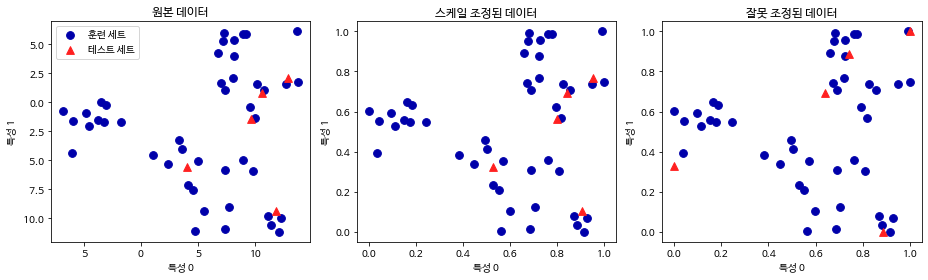

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import mglearn

# 인위적인 데이터셋 생성
X, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
# 훈련 세트와 테스트 세트로 나눕니다
X_train, X_test = train_test_split(X, random_state=5, test_size=.1)

# 훈련 세트와 테스트 세트의 산점도를 그립니다
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(X_train[:, 0], X_train[:, 1],
                c=mglearn.cm2.colors[0], label="훈련 세트", s=60)
axes[0].scatter(X_test[:, 0], X_test[:, 1], marker='^',
                c=mglearn.cm2.colors[1], label="테스트 세트", s=60)
axes[0].legend(loc='upper left')
axes[0].set_title("원본 데이터")

# MinMaxScaler를 사용해 스케일을 조정합니다
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일이 조정된 데이터의 산점도를 그립니다
axes[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
                c=mglearn.cm2.colors[0], label="훈련 세트", s=60)
axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], marker='^',
                c=mglearn.cm2.colors[1], label="테스트 세트", s=60)
axes[1].set_title("스케일 조정된 데이터")

# 테스트 세트의 스케일을 따로 조정합니다
# 테스트 세트의 최솟값은 0, 최댓값은 1이 됩니다
# 이는 예제를 위한 것으로 절대로 이렇게 사용해서는 안됩니다
test_scaler = MinMaxScaler()
test_scaler.fit(X_test)
X_test_scaled_badly = test_scaler.transform(X_test)

# 잘못 조정된 데이터의 산점도를 그립니다
axes[2].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
                c=mglearn.cm2.colors[0], label="training set", s=60)
axes[2].scatter(X_test_scaled_badly[:, 0], X_test_scaled_badly[:, 1],
                marker='^', c=mglearn.cm2.colors[1], label="test set", s=60)
axes[2].set_title("잘못 조정된 데이터")

for ax in axes:
    ax.set_xlabel("특성 0")
    ax.set_ylabel("특성 1")
fig.tight_layout()

특성 표준화

In [ ]:
import numpy as np
from sklearn import preprocessing

x=np.array(
    [[-1000.1],
    [-200.2],
    [500.5],
    [600.6],
    [9000.9]]
)

In [ ]:
scaler=preprocessing.StandardScaler()

standardized=scaler.fit_transform(x)

standardized

array([[-0.76058269],
       [-0.54177196],
       [-0.35009716],
       [-0.32271504],
       [ 1.97516685]])

In [ ]:
# 평균 0, 표준편차 1이 나오는지 확인
print("평균 :", round(standardized.mean()))
print("표준편차:", standardized.std())

평균 : 0
표준편차: 1.0


In [ ]:
# 변환기 객체 
robust_scaler=preprocessing.RobustScaler()

robust_scaler.fit_transform(x)

array([[-1.87387612],
       [-0.875     ],
       [ 0.        ],
       [ 0.125     ],
       [10.61488511]])

In [ ]:
interquatile_range = x[3] - x[1]
(x - np.median(x)) / interquatile_range

array([[-1.87387612],
       [-0.875     ],
       [ 0.        ],
       [ 0.125     ],
       [10.61488511]])

In [ ]:
preprocessing.QuantileTransformer().fit_transform(x)

/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_data.py:2357: UserWarning: n_quantiles (1000) is greater than the total number of samples (5). n_quantiles is set to n_samples.
  % (self.n_quantiles, n_samples))


array([[0.  ],
       [0.25],
       [0.5 ],
       [0.75],
       [1.  ]])

정규화

In [ ]:
import numpy as np
from sklearn.preprocessing import Normalizer

# 특성 행렬을 만듭니다.
features = np.array([[0.5, 0.5],
                     [1.1, 3.4],
                     [1.5, 20.2],
                     [1.63, 34.4],
                     [10.9, 3.3]])

# 변환기 객체를 만듭니다.
normalizer = Normalizer(norm="l2")

# 특성 행렬을 변환합니다.
normalizer.transform(features)

array([[0.70710678, 0.70710678],
       [0.30782029, 0.95144452],
       [0.07405353, 0.99725427],
       [0.04733062, 0.99887928],
       [0.95709822, 0.28976368]])

In [ ]:
# 특성 행렬을 변환합니다.
features_l2_norm = Normalizer(norm="l2").transform(features)

# 특성 행렬을 출력합니다.
features_l2_norm

array([[0.5547002 , 0.83205029],
       [0.5547002 , 0.83205029],
       [0.5547002 , 0.83205029]])

In [ ]:
# 특성 행렬을 변환합니다.
features_l1_norm = Normalizer(norm="l1").transform(features)

# 특성 행렬을 출력합니다.
features_l1_norm

array([[0.4, 0.6],
       [0.4, 0.6],
       [0.4, 0.6]])

In [ ]:
# 합을 출력합니다.
print("첫 번째 샘플 값의 합:",
   features_l1_norm[0, 0] + features_l1_norm[0, 1])

첫 번째 샘플 값의 합: 1.0


In [ ]:
# L1 노름을 사용한 변환.
# 각 행(axis=1)을 합한 결과가 2차원 배열로 유지되도록 keepdims를 True로 설정합니다.
features / np.sum(np.abs(features), axis=1, keepdims=True)

array([[0.4, 0.6],
       [0.4, 0.6],
       [0.4, 0.6]])

In [ ]:
# L2 노름을 사용한 변환.
features / np.sqrt(np.sum(np.square(features), axis=1, keepdims=True))

array([[0.5547002 , 0.83205029],
       [0.5547002 , 0.83205029],
       [0.5547002 , 0.83205029]])

In [ ]:
# 각 행에서 최댓값으로 나눕니다.
Normalizer(norm="max").transform(features)

array([[0.66666667, 1.        ],
       [0.66666667, 1.        ],
       [0.66666667, 1.        ]])

# 다항 특성, 교차항 특성

In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

# 특성 행렬을 만듭니다.
features = np.array([[2, 3],
                     [2, 3],
                     [2, 3]])



# 변환기 객체 생성
poly1=PolynomialFeatures(degree=2, include_bias=False)

# 다항특성 생성
poly1.fit_transform(features)

array([[2., 3., 4., 6., 9.],
       [2., 3., 4., 6., 9.],
       [2., 3., 4., 6., 9.]])

In [ ]:
interaction = PolynomialFeatures(degree=2, 
                                 interaction_only=True, include_bias=False)
interaction.fit_transform(features)

array([[ -9.87755355,  -3.33614544,  32.95295521],
       [ -7.28721033,  -8.35398617,  60.87725431],
       [ -6.94306091,  -7.0237442 ,  48.76628379],
       [ -7.44016713,  -8.79195851,  65.41364076],
       [ -6.64138783,  -8.07588804,  53.63510452],
       [ -0.79415228,   2.10495117,  -1.67165177],
       [ -2.76017908,   5.55121358, -15.32234361],
       [ -9.94690475,  -4.59034419,  45.65971646],
       [ -0.52579046,   3.3065986 ,  -1.73857801],
       [ -1.98197711,   4.02243551,  -7.97237512],
       [ -5.8659643 ,  -7.96807169,  46.74042409],
       [ -6.83478745,  -7.39121692,  50.51739666],
       [ -6.74924724, -10.17542932,  68.67648822],
       [-10.75211044,  -2.70048039,  29.03586343],
       [ -8.50899599,  -8.65769397,  73.66828324],
       [ -2.33080604,   4.39382527, -10.24115446],
       [ -0.19745197,   2.34634916,  -0.46329126],
       [  0.08525186,   3.64528297,   0.31076715],
       [-10.20660674,  -3.36672536,  34.3628417 ],
       [ -9.15872909,  -3.02224

특성 변환

In [ ]:
# 라이브러리를 임포트합니다.
import numpy as np
from sklearn.preprocessing import FunctionTransformer

# 특성 행렬을 만듭니다.
features = np.array([[2, 3],
                     [2, 3],
                     [2, 3]])

# 간단한 함수를 정의합니다.
def add_ten(x):
    return x + 10

# 변환기 객체를 만듭니다.
ten_transformer = FunctionTransformer(add_ten)

# 특성 행렬을 변환합니다.
ten_transformer.transform(features)

array([[12, 13],
       [12, 13],
       [12, 13]])

In [ ]:
# 라이브러리를 임포트합니다.
import pandas as pd

# 데이터프레임을 만듭니다.
df = pd.DataFrame(features, columns=["feature_1", "feature_2"])

# 함수를 적용합니다.
df.apply(add_ten)

,feature_1,feature_2
0,12,13
1,12,13
2,12,13


In [ ]:
FunctionTransformer(add_ten, validate=False).transform(np.array([1, 2, 3]))

array([11, 12, 13])

In [ ]:
from sklearn.compose import ColumnTransformer

# 100을 더하는 함수를 만듭니다.
def add_hundred(x):
    return x + 100

# (이름, 변환기, 열 리스트)로 구성된 튜플의 리스트를 ColumnTransformer에 전달합니다.
ct = ColumnTransformer(
    [("add_ten", FunctionTransformer(add_ten, validate=True), ['feature_1']),
     ("add_hundred", FunctionTransformer(add_hundred, validate=True), ['feature_2'])])

ct.fit_transform(df)

array([[ 12, 103],
       [ 12, 103],
       [ 12, 103]])

# 이상치 문제

이상치 확인
1. 알고리즘
2. IQR

In [ ]:
# 데이터 셋 생성
# 라이브러리를 임포트합니다.
import numpy as np
from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import make_blobs

# 모의 데이터를 만듭니다.
features, _ = make_blobs(n_samples = 10,
                         n_features = 2,
                         centers = 1,
                         random_state = 1)

# 임의의 이상치 생성-첫 번째 행에 대해 극단값 생성

features[0,0]=10000
features[0,1]=10000

print(features)

[[ 1.00000000e+04  1.00000000e+04]
 [-2.76017908e+00  5.55121358e+00]
 [-1.61734616e+00  4.98930508e+00]
 [-5.25790464e-01  3.30659860e+00]
 [ 8.52518583e-02  3.64528297e+00]
 [-7.94152277e-01  2.10495117e+00]
 [-1.34052081e+00  4.15711949e+00]
 [-1.98197711e+00  4.02243551e+00]
 [-2.18773166e+00  3.33352125e+00]
 [-1.97451969e-01  2.34634916e+00]]


In [ ]:
# 1. 타원 알고리즘을 이용한 이상치 확인 방법

# 이상치 감지 객체 생성
outlier_detector=EllipticEnvelope(contamination=.1)

# 객체 훈련
outlier_detector.fit(features)

# 이상치 예측
outlier_detector.predict(features)

array([-1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [ ]:
# IQR   1.5 이상 < 1사분위 3사분위 < 1.5 이상 에 대해서 이상치로 정의해주는 함수 생성

def indicies_of_outliers(x):
  q1, q3=np.percentile(x, [25, 75])
  iqr=q3-q1
  lower_bound=q1-(iqr*1.5)
  upper_bound=q3+(iqr*1.5)
  return np.where((x > upper_bound) | (x<lower_bound))

In [ ]:
# 특성 생성
feature=features[:,0]

feature

array([ 1.00000000e+04, -2.76017908e+00, -1.61734616e+00, -5.25790464e-01,
        8.52518583e-02, -7.94152277e-01, -1.34052081e+00, -1.98197711e+00,
       -2.18773166e+00, -1.97451969e-01])

In [ ]:
#함수 호출
indicies_of_outliers(feature)

(array([0]),)

이상치 조작

In [ ]:
# 데이터 셋 생성
# 라이브러리를 임포트합니다.
import pandas as pd

# 데이터프레임을 만듭니다.
houses = pd.DataFrame()
houses['Price'] = [534433, 392333, 293222, 4322032]
houses['Bathrooms'] = [2, 3.5, 2, 116]
houses['Square_Feet'] = [1500, 2500, 1500, 48000]

houses

,Price,Bathrooms,Square_Feet
0,534433,2.0,1500
1,392333,3.5,2500
2,293222,2.0,1500
3,4322032,116.0,48000


In [ ]:
indicies_of_outliers(houses['Bathrooms'])

(array([3]),)

In [ ]:
# 필터링을 통한 샘플링 -> 이상치 제거
houses[houses['Bathrooms'] < 20]

,Price,Bathrooms,Square_Feet
0,534433,2.0,1500
1,392333,3.5,2500
2,293222,2.0,1500


In [ ]:
# 필터링 되어진 데이터 셋을 통해 특성 생성
import numpy as np

houses["Outlier"]=np.where(houses["Bathrooms"] < 20, 0, 1)

houses

,Price,Bathrooms,Square_Feet,Outlier
0,534433,2.0,1500,0
1,392333,3.5,2500,0
2,293222,2.0,1500,0
3,4322032,116.0,48000,1


In [ ]:
# 로그 특성
houses["Log_Of_Square_Feet"] = [np.log(x) for x in houses["Square_Feet"]]

# 데이터를 확인합니다.
houses

,Price,Bathrooms,Square_Feet,Outlier,Log_Of_Square_Feet
0,534433,2.0,1500,0,7.313220
1,392333,3.5,2500,0,7.824046
2,293222,2.0,1500,0,7.313220
3,4322032,116.0,48000,1,10.778956


특성 이산화

In [ ]:
# 라이브러리를 임포트합니다.
import numpy as np
from sklearn.preprocessing import Binarizer

# 특성을 만듭니다.
age = np.array([[6],
                [12],
                [20],
                [36],
                [65]])

# Binarizer 객체를 만듭니다.
binarizer = Binarizer(threshold=18)

# 특성을 변환합니다.
binarizer.fit_transform(age)

array([[0],
       [0],
       [1],
       [1],
       [1]])

In [ ]:
# 특성을 나눕니다.
np.digitize(age, bins=[20,30,64])

array([[0],
       [0],
       [1],
       [2],
       [3]])

In [ ]:
# 특성을 나눕니다.
np.digitize(age, bins=[20,30,64], right=True)

array([[0],
       [0],
       [0],
       [2],
       [3]])

In [ ]:
# 특성을 나눕니다.
np.digitize(age, bins=[18])

array([[0],
       [0],
       [1],
       [1],
       [1]])

# 결측치

1. 결측치  제거
2. 결측치 채우기

In [ ]:
# 라이브러리를 임포트합니다.
import numpy as np

# 특성 행렬을 만듭니다.
features = np.array([[1.1, 11.1],
                     [2.2, 22.2],
                     [3.3, 33.3],
                     [4.4, 44.4],
                     [np.nan, 55]])

features

array([[ 1.1, 11.1],
       [ 2.2, 22.2],
       [ 3.3, 33.3],
       [ 4.4, 44.4],
       [ nan, 55. ]])

In [ ]:
# 제거
features[~np.isnan(features).any(axis=1)]

array([[ 1.1, 11.1],
       [ 2.2, 22.2],
       [ 3.3, 33.3],
       [ 4.4, 44.4]])

In [ ]:
import pandas as pd

df1=pd.DataFrame(features, columns=["feature_1","feature_2"])

df1

,feature_1,feature_2
0,1.1,11.1
1,2.2,22.2
2,3.3,33.3
3,4.4,44.4
4,NaN,55.0


In [ ]:
df1.dropna()

,feature_1,feature_2
0,1.1,11.1
1,2.2,22.2
2,3.3,33.3
3,4.4,44.4


In [ ]:
# 결측치 채우기

# 라이브러리를 임포트합니다.
import numpy as np
from fancyimpute import KNN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# 모의 특성 행렬을 만듭니다.
features, _ = make_blobs(n_samples = 1000,
                         n_features = 2,
                         random_state = 1)

print(features)

/usr/local/lib/python3.6/dist-packages/sklearn/externals/six.py:31: FutureWarning: The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).
  "(https://pypi.org/project/six/).", FutureWarning)


[[-3.05837272  4.48825769]
 [-8.60973869 -3.72714879]
 [ 1.37129721  5.23107449]
 ...
 [-1.91854276  4.59578307]
 [-1.79600465  4.28743568]
 [-6.97684609 -8.89498834]]


In [ ]:
# 특성을 표준화
scaler=StandardScaler()

stand_features=scaler.fit_transform(features)

print(stand_features)

[[ 0.87301861  1.31426523]
 [-0.67073178 -0.22369263]
 [ 2.1048424   1.45332359]
 ...
 [ 1.18998798  1.33439442]
 [ 1.22406396  1.27667052]
 [-0.21664919 -1.19113343]]


In [ ]:
# 첫번째 행을 삭제해서 결측치를 생성
true_value=stand_features[0,0]
stand_features[0,0]=np.nan

print(stand_features)

[[        nan  1.31426523]
 [-0.67073178 -0.22369263]
 [ 2.1048424   1.45332359]
 ...
 [ 1.18998798  1.33439442]
 [ 1.22406396  1.27667052]
 [-0.21664919 -1.19113343]]


In [ ]:
# 특성 행렬에 있는 결측치 대체 코드
features_knn=KNN(k=5, verbose=0).fit_transform(stand_features)

features_knn

array([[ 1.09553327,  1.31426523],
       [-0.67073178, -0.22369263],
       [ 2.1048424 ,  1.45332359],
       ...,
       [ 1.18998798,  1.33439442],
       [ 1.22406396,  1.27667052],
       [-0.21664919, -1.19113343]])

In [ ]:
# 실제 데이터와 대체된 값 비교해 보기
print("실제값: ", true_value)
print("대체된 값: ", features_knn[0,0])

실제값:  0.8730186113995938
대체된 값:  1.0955332713113226


구간화 : 군집으로 샘플링 그룹처리

In [ ]:
# 라이브러리를 임포트합니다.
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 모의 특성 행렬을 만듭니다.
features, _ = make_blobs(n_samples = 50,
                         n_features = 2,
                         centers = 3,
                         random_state = 1)

features[6:8]

array([[-2.76017908,  5.55121358],
       [-9.94690475, -4.59034419]])

In [ ]:
# 데이터 프레임 생성
df1=pd.DataFrame(features, columns=["Field1","Field2"])

df1.head(5)

,Field1,Field2
0,-9.877554,-3.336145
1,-7.287210,-8.353986
2,-6.943061,-7.023744
3,-7.440167,-8.791959
4,-6.641388,-8.075888


In [ ]:
#k-평균 군집 모델
cluster=KMeans(3, random_state=0)

cluster

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=0, tol=0.0001, verbose=0)

In [ ]:
#모델 훈련
cluster.fit(features)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=0, tol=0.0001, verbose=0)

In [ ]:
#그룹 처리
df1["group"]=cluster.predict(features)

In [ ]:
df1.head(5)

,Field1,Field2,group
0,-9.877554,-3.336145,2
1,-7.287210,-8.353986,0
2,-6.943061,-7.023744,0
3,-7.440167,-8.791959,0
4,-6.641388,-8.075888,0


In [ ]:
df1.tail(5)

,Field1,Field2,group
45,-9.509194,-4.028920,2
46,-8.337910,-3.211304,2
47,-9.712125,-3.068207,2
48,-8.866083,-2.433532,2
49,-7.684883,-7.455196,0
